1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?
2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?
3. ¿Cuál es la distribución de los clientes por provincia o estado?
4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?
5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?
6. ¿Cómo se distribuyen los clientes según su estado civil y género?

In [1]:
# importamos las librerías 

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
#abrimos csv
df_clientes = pd.read_csv("clientes_limpio.csv")
df_info_vuelos = pd.read_csv("vuelos_limpio.csv")
df_final = pd.read_csv("info_unida.csv")

Text(0.5, 1.0, 'Reservas de Vuelos por Mes')

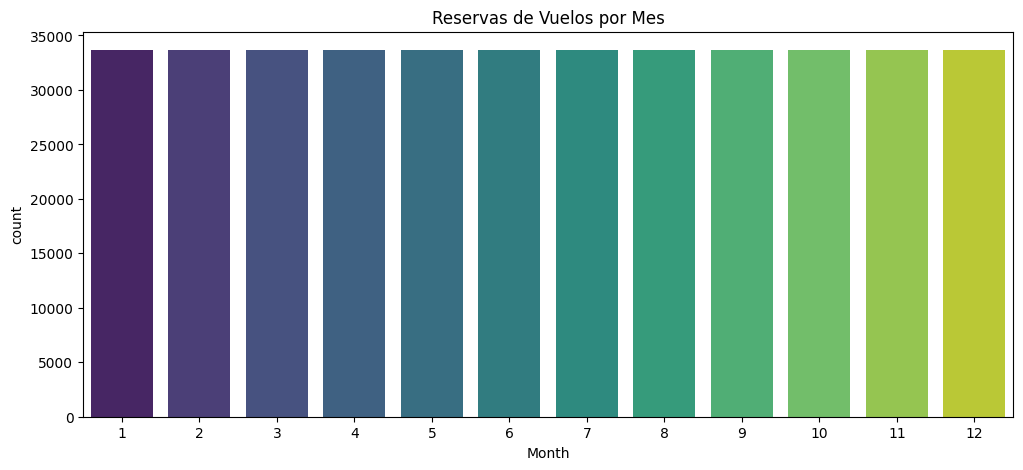

In [3]:
#1
plt.figure(figsize=(12,5))
sns.countplot(data=df_info_vuelos, x="Month", palette="viridis")
plt.title("Reservas de Vuelos por Mes")

Interpretación : Se mantiene estable el nivel de vuelos durante todo el año sin grandes diferencias 

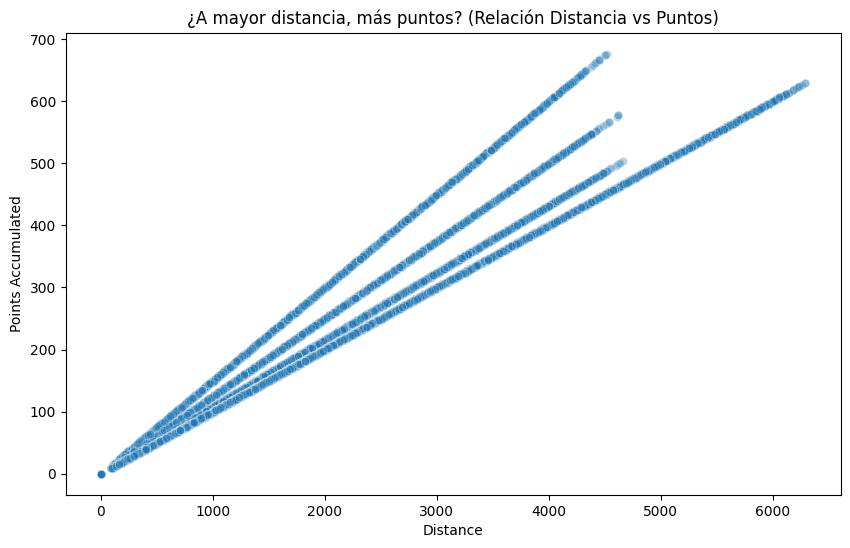

In [4]:
#2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_info_vuelos, x="Distance", y="Points Accumulated", alpha=0.3)
plt.title("¿A mayor distancia, más puntos? (Relación Distancia vs Puntos)")
plt.show()

Interpretación : Hay una clara tendencia entre la distancia y los puntos acumulados a más distancia más puntos

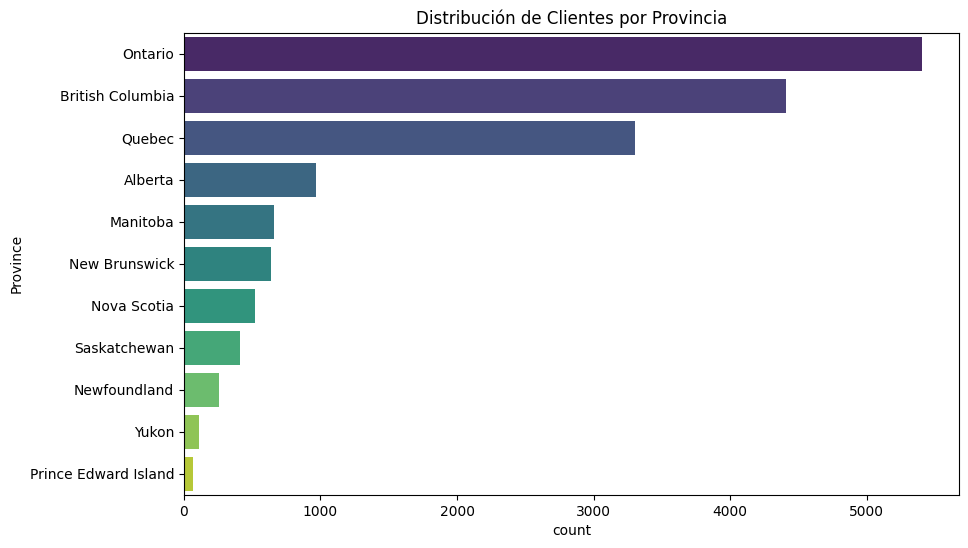

In [5]:
#3
plt.figure(figsize=(10, 6))
# Contamos cuántos clientes únicos hay por provincia
sns.countplot(data=df_clientes, y="Province", order=df_clientes["Province"].value_counts().index, palette="viridis")
plt.title("Distribución de Clientes por Provincia")
plt.show()

Interpretación : Se puede apreciar con este diagrama que las tres provincias con más clientes son tambien las más extentesas en población.Esta empresa debe centrar sus esfuerzos en las provincias con menos clientes

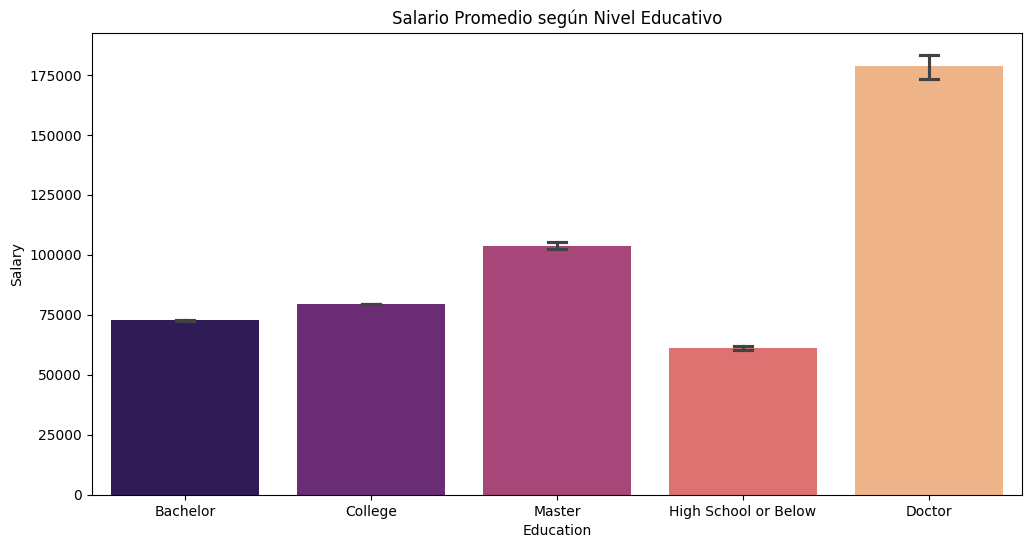

In [6]:
#4
plt.figure(figsize=(12, 6))
sns.barplot(data=df_clientes, x="Education", y="Salary", palette="magma", capsize=.1)
plt.title("Salario Promedio según Nivel Educativo")
plt.show()

Interpretación : Hay una relación posita entre nivel educativo y salario,que valida el patrón socieconómico lógico

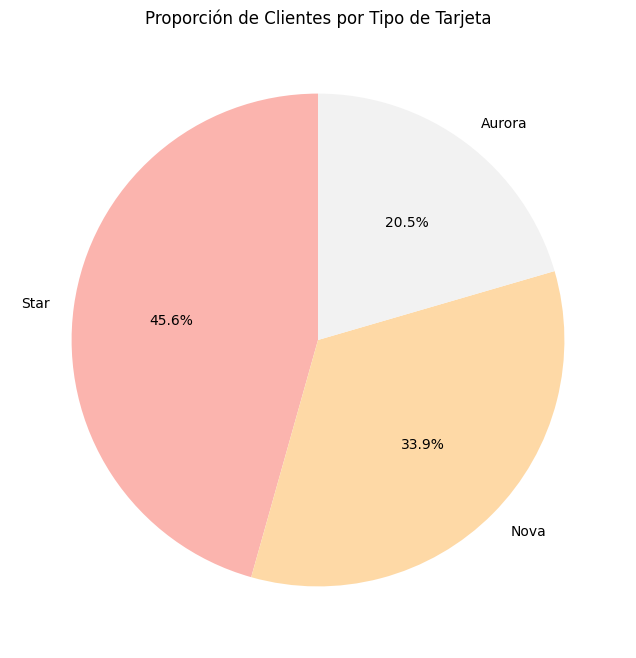

In [7]:
#4
plt.figure(figsize=(8, 8))
df_clientes["Loyalty Card"].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap="Pastel1")
plt.title("Proporción de Clientes por Tipo de Tarjeta")
plt.ylabel("") # Eliminamos la etiqueta vertical para que se vea limpio
plt.show()

Interpretación : Se puede apreciar en el gráfico que casi la mitad de los datos corresposnde a la tarjeta star. Se nececita una estrategía de fidelización clara para las otras dos tarjetas 

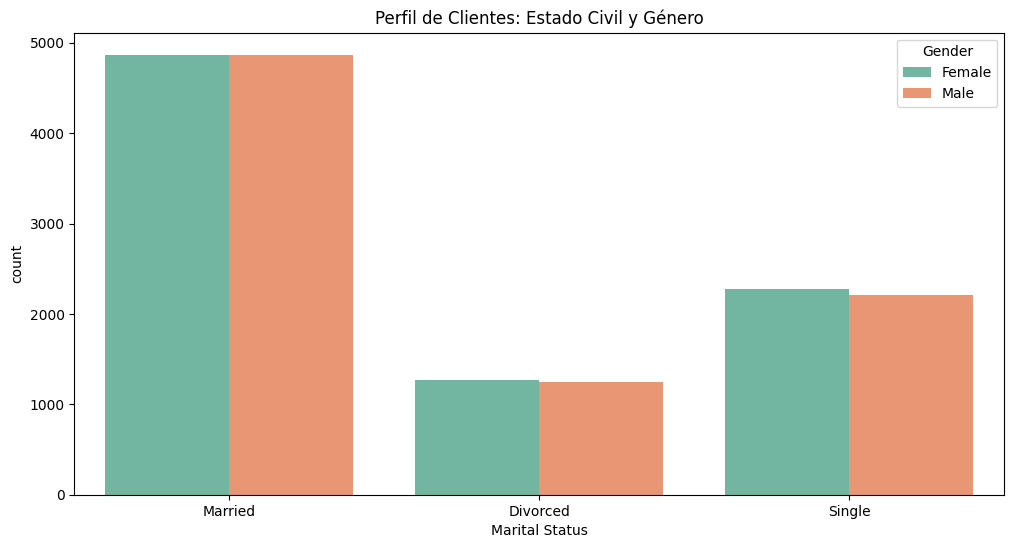

In [8]:
#6
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clientes, x="Marital Status", hue="Gender", palette="Set2")
plt.title("Perfil de Clientes: Estado Civil y Género")
plt.show()

Interpretación : El perfil dominate es casados sin diferenciación entre géneros.Los que significa que el género no influye en esta distribución. El estado civil sería más relevante en este caso

## Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo 

In [9]:
# Filtramos las columnas relevantes
df_vuelos_educacion = df_final[['Flights Booked', 'Education']]

# Mostramos las primeras filas para confirmar
df_vuelos_educacion.head(2)

,Flights Booked,Education
0,0,Bachelor
1,3,Bachelor


In [ ]:
# Agrupamos por Education y calculamos las estadísticas
stats_educacion = df_vuelos_educacion.groupby('Education')['Flights Booked'].agg(['count', 'mean', 'std', 'median']).reset_index()

# Renombramos las columnas
stats_educacion.columns = ['Nivel Educativo', 'Total Clientes', 'Promedio Vuelos', 'Desviación Estándar', 'Mediana']

# Ordenamos por promedio para ver quién vuela más
stats_educacion = stats_educacion.sort_values(by='Promedio Vuelos', ascending=True)
stats_educacion

,Nivel Educativo,Total Clientes,Promedio Vuelos,Desviación Estándar,Mediana
0,Bachelor,252567,4.110288,5.221671,1.0
1,College,102260,4.169744,5.246040,1.0
2,Doctor,17731,4.175512,5.256971,1.0
3,High School or Below,18915,4.176209,5.239267,1.0
4,Master,12287,4.200700,5.213956,1.0


<Axes: xlabel='Education', ylabel='Flights Booked'>

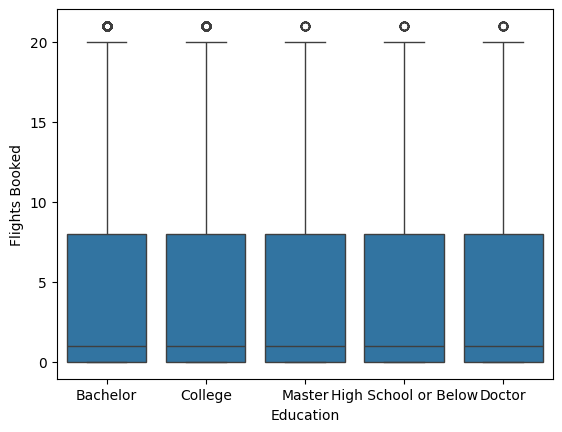

In [5]:
sns.boxplot(x='Education', y='Flights Booked', data=df_final)

Interpretación : No hay una desviación clara entre los niveles de estudios y lo vuelos que pueda justificar que un grupo educativo vuela más que otro